# Dataset description
## Laboral Productivity over the years

**Source**: DANE

**Download**: [link](https://www.dane.gov.co/index.php/estadisticas-por-tema/cuentas-nacionales/productividad)

# Code
## Imports

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from highlight_text import fig_text
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from pathlib import Path

BASE_DIR = Path.cwd().parent.parent
pd.set_option("display.float_format", lambda x: "%.2f" % x)

## Load data

In [49]:
logo_path = BASE_DIR / "logo/logo.png"
path_p = "./data/por_persona_empleada.csv"
path_h = "./data/por_hora_trabajada.csv"

df_p = pd.read_csv(path_p, encoding="utf-8", usecols=[0,1])
df_h = pd.read_csv(path_h, encoding="utf-8", usecols=[0,1])
logo = plt.imread(logo_path)

## Clean Data

In [50]:
df = pd.merge(df_p, df_h, on="año", how="inner")

## Plot

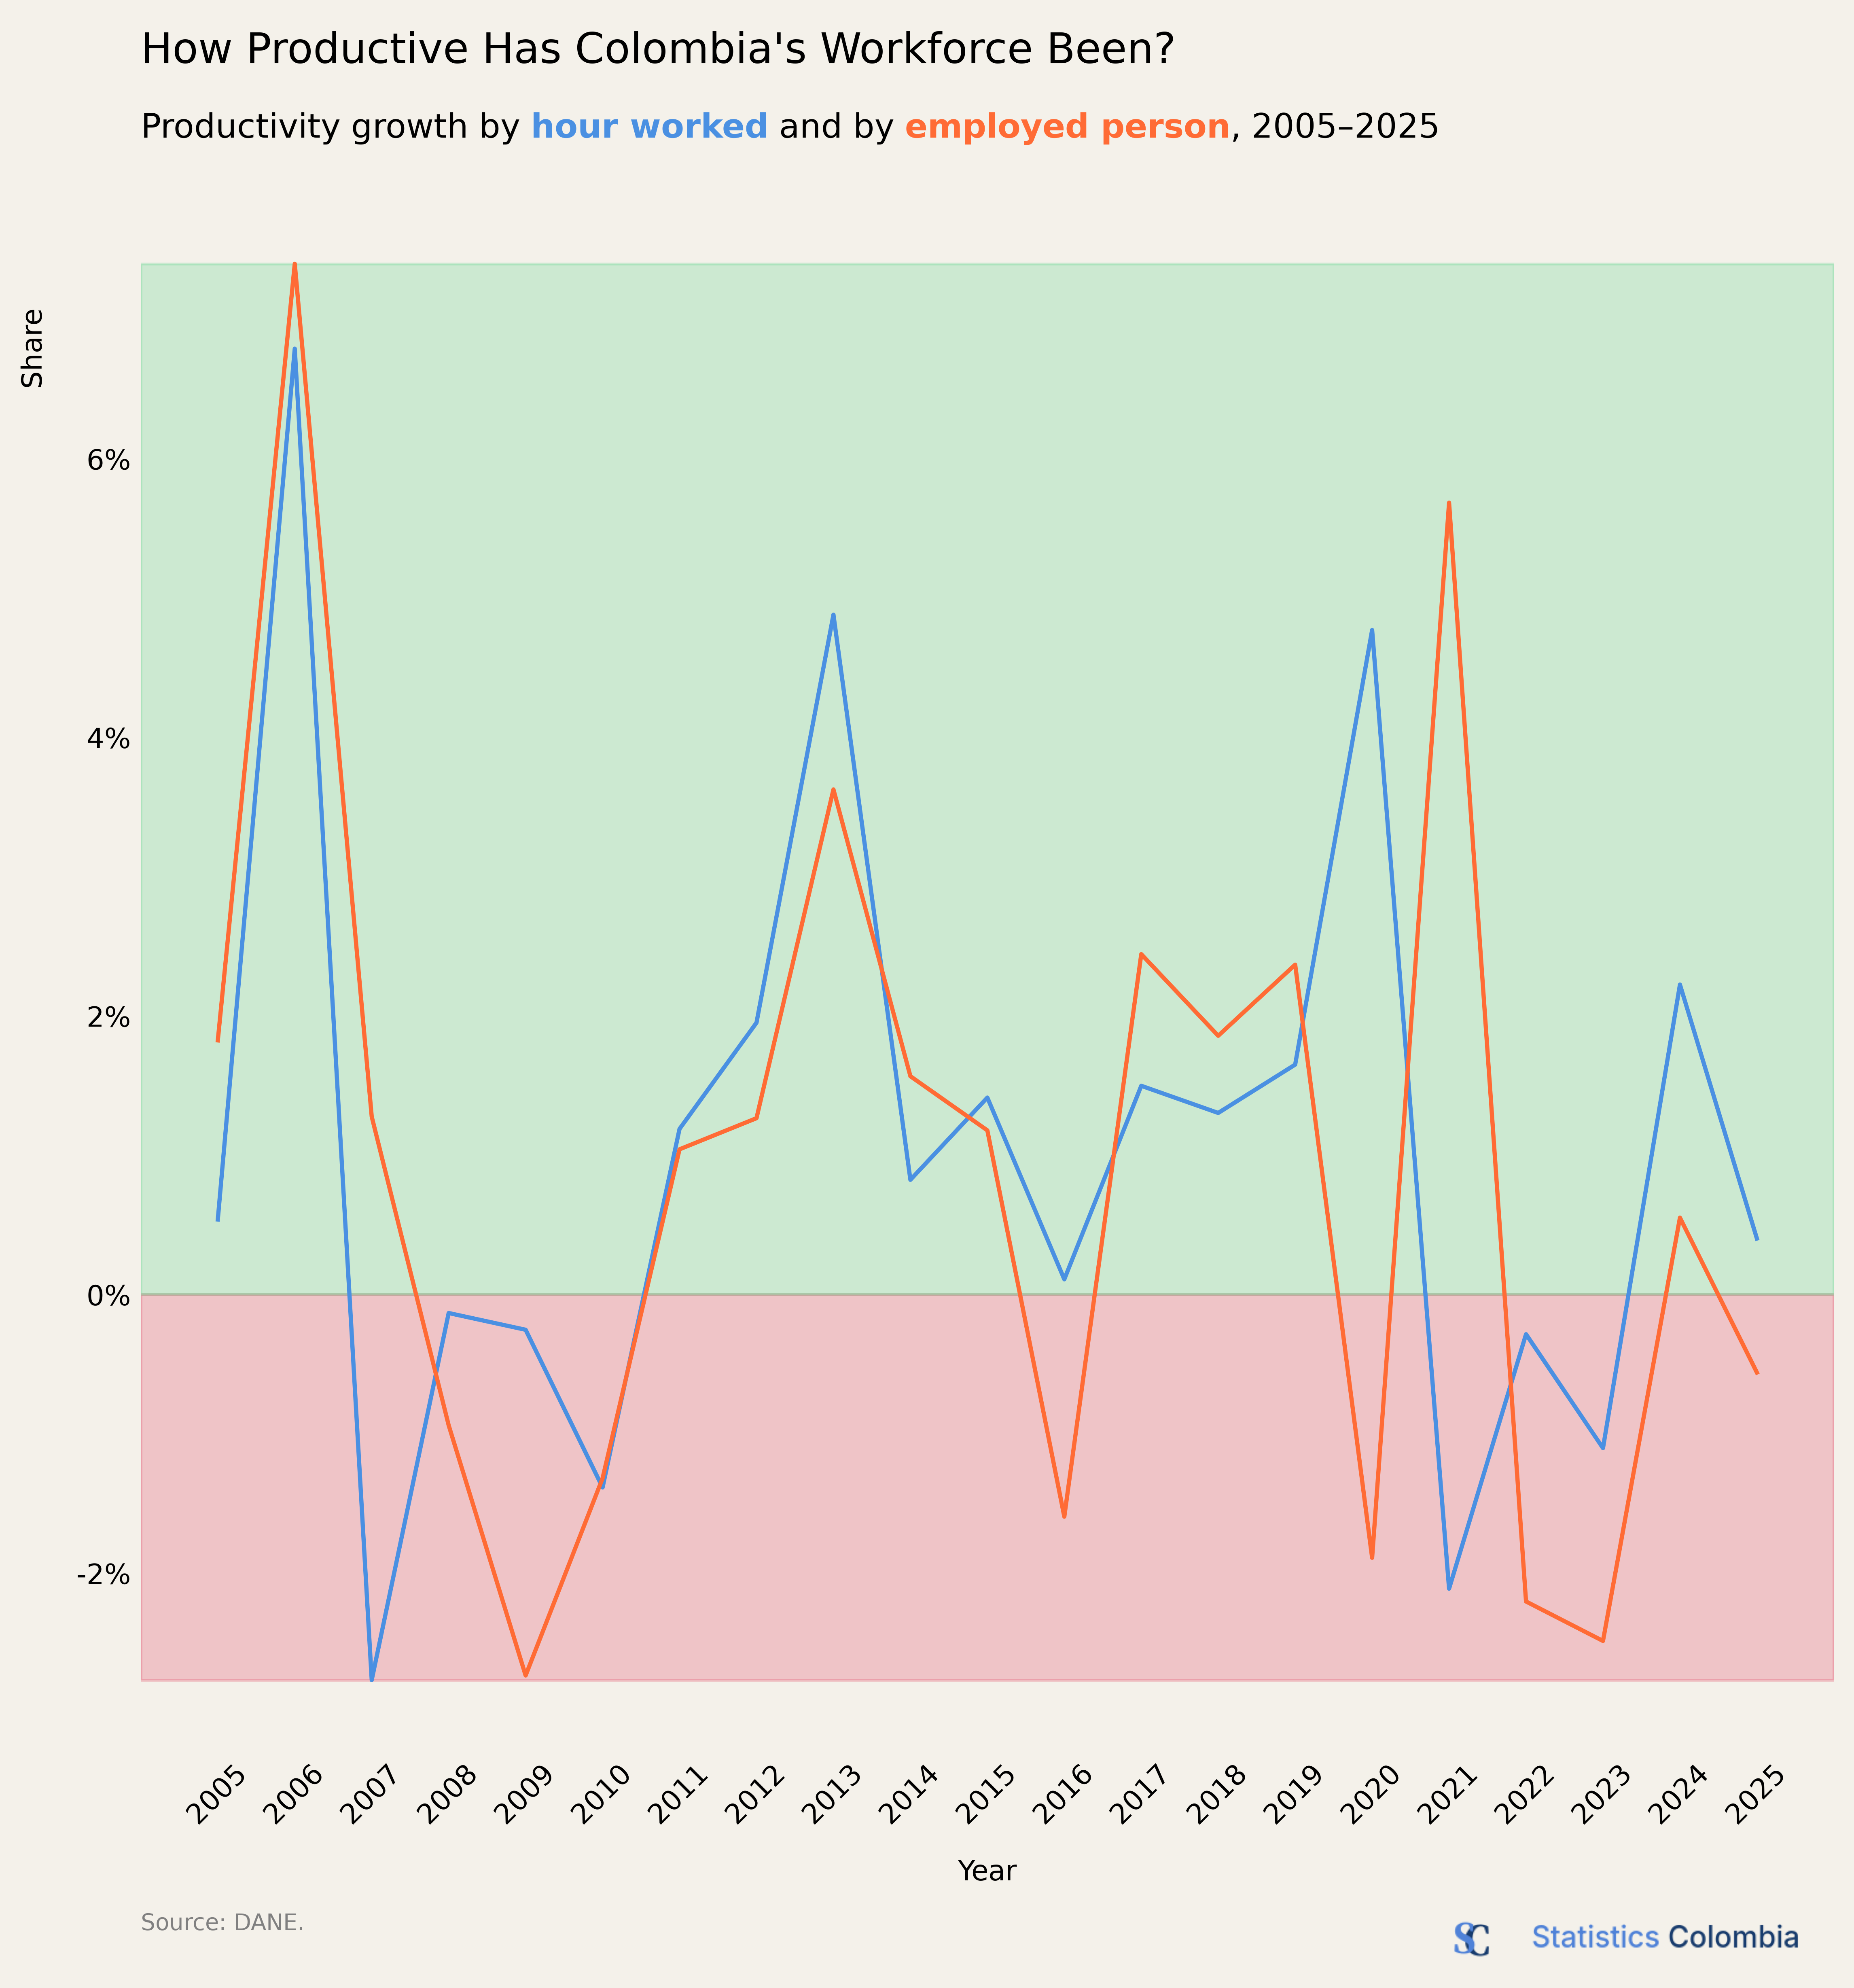

In [51]:
x_axis = df["año"]
background = "#F4F1EA"
blue = "#4a90e2"
orange = "#FF6B35"
red = "#DC143C"
green = "#2ecc71"

fig, ax = plt.subplots(figsize=(10.8, 10), dpi=500)
fig.patch.set_facecolor(background)
ax.patch.set_facecolor(background)

plt.plot(x_axis, df["productividad laboral por hora trabajada (%)"], color=blue)
plt.plot(x_axis, df["productividad laboral por persona empleada (%)"], color=orange)

plt.xticks(x_axis, rotation=45)


min = df[["productividad laboral por hora trabajada (%)", "productividad laboral por persona empleada (%)"]].values.min()

max = df[["productividad laboral por hora trabajada (%)", "productividad laboral por persona empleada (%)"]].values.max()

plt.axhspan(ymin=min, ymax=0, color=red, alpha=0.2)
plt.axhspan(ymin=0, ymax=max, color=green, alpha=0.2)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.xlabel("Year", labelpad=10, fontsize=10)
plt.ylabel("Share", labelpad=10, fontsize=10, y=0.9)

fig_text(
    x=0.125, y=0.96,
    s="How Productive Has Colombia's Workforce Been?",
    fontsize=15
)

fig_text(
    x=0.125, y=0.92,
    s="Productivity growth by <hour worked> and by <employed person>, 2005–2025",
    highlight_textprops=[
        {"color": blue, "weight": "bold"},
        {"color": orange, "weight": "bold"}
    ],
    fontsize=12
)

fig_text(
    0.125, 0.03, 
    "Source: DANE.\n", 
    fontsize=8, color="gray",
)

imagebox = OffsetImage(logo, zoom=0.4)

ab = AnnotationBbox(imagebox, xy=(0.75, 0.025), xycoords="figure fraction",
                    frameon=False, pad=0)

plt.gca().add_artist(ab)

plt.show()